In [3]:
# Each sample has 3 features: [area, bedrooms, bathrooms]
X = [
    [2100, 3, 2],
    [1600, 2, 1],
    [2400, 4, 3],
    [1416, 2, 2],
    [3000, 4, 3]
]

# Corresponding house prices
y = [400000, 330000, 450000, 232000, 540000]
print(X)
print(y)


[[2100, 3, 2], [1600, 2, 1], [2400, 4, 3], [1416, 2, 2], [3000, 4, 3]]
[400000, 330000, 450000, 232000, 540000]


In [9]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X)
print(y)

n_features = X.shape[1]
print(f"features = {n_features}")
w = np.random.rand(n_features)
b = np.random.rand()

print(w)
print(b)

[[2100    3    2]
 [1600    2    1]
 [2400    4    3]
 [1416    2    2]
 [3000    4    3]]
[400000 330000 450000 232000 540000]
features = 3
[0.31898758 0.48985809 0.44550416]
0.21551120099261978


In [12]:
def predict(w, b , X):
    return np.dot(w , X) + b


In [13]:
def compute_cost(X, y, w, b):
    n = X.shape[0]
    total_error = 0.0
    for i in range(n):
        y_hat = predict(w, b ,X[i])
        error  = y_hat - y[i]
        error = error**2
        total_error += error
    cost = total_error/n
    return cost

In [14]:
def compute_gradients(X, y, w, b):
    n = X.shape[0]
    dw = np.zeros(n_features)
    db = 0.0
    for i in range(n):
        y_hat =predict(w, b, X[i])
        error = y_hat - y[i]
        for j in range(n_features):
            dw[j] += error*X[i][j]
        db += error
    dw = (2/n) * dw
    db = (2/n) * db
    return dw, db

In [15]:
def update_parameters(dw, db , w ,b, learning_rate):
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w, b

In [16]:
def train(X, y , w, b , learning_rate, epochs):
    for epoch in range(epochs):
        cost = compute_cost(X, y , w , b)

        dw, db = compute_gradients(X, y, w, b)

        w, b = update_parameters(dw, db, w , b, learning_rate)

        print(f"Epoch {epoch+1}: Cost={cost:.2f}, w={w}, b={b:.2f}")

    return w, b



In [19]:
learning_rate = 0.00000001
epochs = 1000

w_final, b_final = train(X, y,w, b, learning_rate, epochs)


Epoch 1: Cost=162802100878.15, w=[17.87463102  0.51495062  0.46372835], b=0.22
Epoch 2: Cost=133444978464.87, w=[33.7635322   0.53766035  0.48020877], b=0.23
Epoch 3: Cost=109397601717.90, w=[48.14393253  0.5582135   0.49511096], b=0.24
Epoch 4: Cost=89699610876.98, w=[61.15904989  0.57681483  0.50858478], b=0.24
Epoch 5: Cost=73564343930.67, w=[72.93850498  0.59364963  0.52076582], b=0.25
Epoch 6: Cost=60347420360.52, w=[83.59961226  0.60888563  0.53177683], b=0.25
Epoch 7: Cost=49521007060.92, w=[93.24854826  0.62267461  0.5417289 ], b=0.26
Epoch 8: Cost=40652738714.45, w=[101.98140907   0.63515396   0.55072254], b=0.26
Epoch 9: Cost=33388450783.71, w=[109.88516738   0.646448     0.55884877], b=0.26
Epoch 10: Cost=27438035541.43, w=[117.03853861   0.65666929   0.56618993], b=0.27
Epoch 11: Cost=22563856283.45, w=[123.51276492   0.66591965   0.57282056], b=0.27
Epoch 12: Cost=18571257032.47, w=[129.3723247    0.67429128   0.57880812], b=0.27
Epoch 13: Cost=15300788726.83, w=[134.67557

len(y): 5
len(y_preds): 5


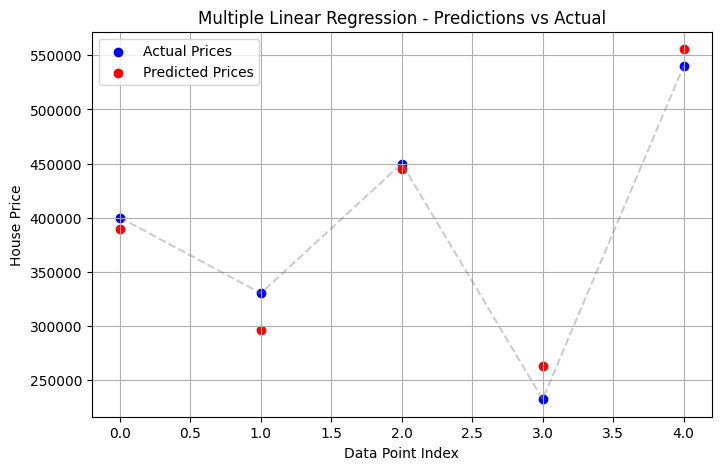

In [28]:

y_preds = [predict(w_final, b_final, x ) for x in X]
print("len(y):", len(y))
print("len(y_preds):", len(y_preds))


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Actual values (blue)
plt.scatter(range(len(y)), y, label="Actual Prices", color='blue')

# Predicted values (red)
plt.scatter(range(len(y_preds)), y_preds, label="Predicted Prices", color='red')

# Optional: Line to show actual trend
plt.plot(range(len(y)), y, linestyle='dashed', color='gray', alpha=0.4)

plt.xlabel("Data Point Index")
plt.ylabel("House Price")
plt.title("Multiple Linear Regression - Predictions vs Actual")
plt.legend()
plt.grid(True)
plt.show()
